In [1]:
import tensorflow as tf
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
model=tf.keras.models.load_model('trained_model.keras')

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Visualizing Single Image

In [4]:
import cv2

In [7]:
image_path="dataset-2/test/Apple___healthy/00a6039c-e425-4f7d-81b1-d6b0e668517e___RS_HL 7669.JPG"

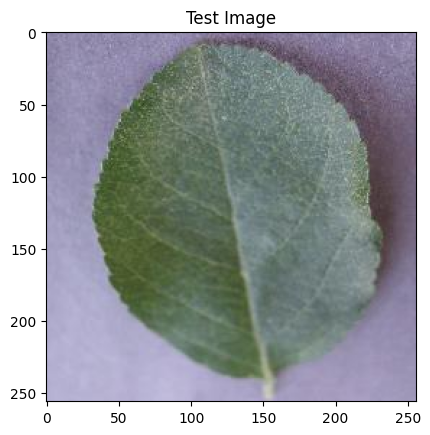

In [8]:
img=cv2.imread(image_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Test Image")
plt.show()

## Testing Model

In [9]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
image_arr = tf.keras.preprocessing.image.img_to_array(image)
image_arr=np.array([image_arr])
print(image_arr.shape)

(1, 128, 128, 3)


In [10]:
prediction = model.predict(image_arr)
prediction,prediction.shape

1/1 [==============================] - 10s 10s/step


(array([[5.6608446e-02, 3.2708724e-06, 1.2221859e-09, 9.4338500e-01,
         6.8492324e-07, 6.7295957e-08, 6.2489386e-10, 1.2560813e-08,
         3.5308811e-11, 2.8008243e-10, 9.9586424e-12, 1.0774886e-11,
         1.5334602e-11, 1.6603965e-13, 2.5820535e-07, 2.4443477e-07,
         4.9122466e-09, 1.3838553e-11, 1.9367338e-12, 6.9339812e-11,
         3.0977829e-10, 1.9144243e-06, 2.9263824e-11, 8.3460938e-12,
         9.3136357e-08, 4.1092236e-09, 1.7501064e-09, 2.1868436e-08,
         6.8712276e-09, 1.8113807e-12, 2.9066749e-10, 3.1038452e-10,
         2.1468489e-09, 7.3184930e-11, 5.8909309e-09, 1.3321860e-12,
         3.6650389e-13, 3.0708424e-08]], dtype=float32),
 (1, 38))

In [11]:
result_index = np.argmax(prediction)
result_index

3

In [12]:
class_name=['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

## Display Result

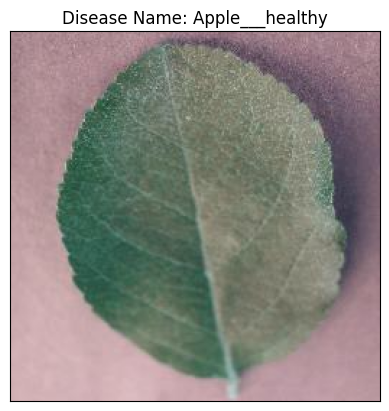

In [13]:
model_prediction = class_name[result_index]

img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title(f"Disease Name: { model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [14]:
model_prediction

'Apple___healthy'